## Comparison by difficulty

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
group_cols = ["seed", "example_id", "bucket", "level"]
order = ["easy", "medium", "hard"]

In [28]:


csv_path = "/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen3-4B-Thinking-2507_vs_Qwen3-30B-A3B-Thinking-2507_1768301480.csv"
df = pd.read_csv(csv_path)

# safe log transform
df["ratio"] = df["ratio_pA_over_pB"].clip(lower=1e-30)
df["log10_ratio"] = np.log10(df["ratio"])
df["abs_log10_ratio"] = df["log10_ratio"].abs()

df.head()


,seed,example_id,bucket,level,prompt,continuation_text,token_idx,token_id,token_str,p_a,p_b,ratio_pA_over_pB,ratio,log10_ratio,abs_log10_ratio
0,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,0,1249,To,0.917652,0.862054,1.064494,1.064494,0.027143,0.027143
1,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,1,1477,find,0.939413,0.861212,1.090803,1.090803,0.037746,0.037746
2,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,2,279,the,0.997105,0.999594,0.997510,0.997510,-0.001083,0.001083
3,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,3,24632,smallest,0.999898,0.991068,1.008910,1.008910,0.003852,0.003852
4,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,4,5248,multiple,0.999989,0.999969,1.000020,1.000020,0.000009,0.000009


In [29]:
group_cols = ["seed", "example_id", "bucket", "level"]

per_problem = df.groupby(group_cols).agg(
    n_tokens=("token_idx", "count"),
    mean_abs_log10=("abs_log10_ratio", "mean"),
    p95_abs_log10=("abs_log10_ratio", lambda x: np.percentile(x, 95)),
    max_abs_log10=("abs_log10_ratio", "max"),
).reset_index()

per_problem.sort_values(["bucket","level","p95_abs_log10"], ascending=[True, True, False]).head(15)


,seed,example_id,bucket,level,n_tokens,mean_abs_log10,p95_abs_log10,max_abs_log10
0,42,test_105,easy,1,500,0.111936,0.624956,1.713427
11,42,test_466,easy,1,500,0.106008,0.587400,4.003652
8,42,test_3927,easy,1,500,0.091209,0.454822,2.341119
9,42,test_4371,easy,2,500,0.110162,0.665586,3.657574
3,42,test_1542,easy,2,500,0.074562,0.401553,1.621818
2,42,test_1416,easy,2,500,0.060625,0.373858,1.560746
6,42,test_267,hard,5,500,0.079819,0.471786,2.731305
7,42,test_3110,hard,5,500,0.068860,0.422207,3.196136
5,42,test_257,hard,5,500,0.071171,0.357614,3.945973
14,42,test_933,medium,3,500,0.173142,0.814504,5.444797


/tmp/ipykernel_3510600/434062113.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order)


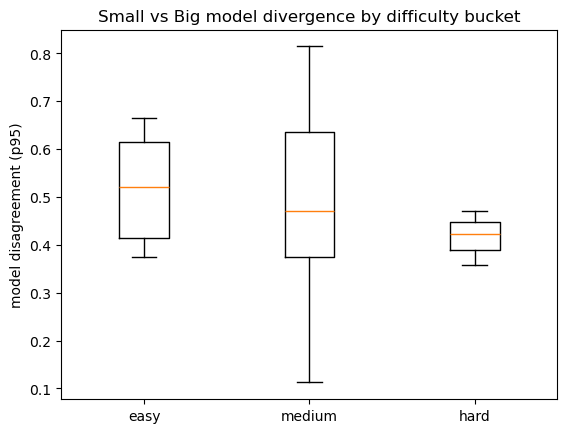

In [30]:

data = [per_problem.loc[per_problem["bucket"]==b, "p95_abs_log10"].values for b in order]

plt.figure()
plt.boxplot(data, labels=order)
plt.ylabel("model disagreement (p95)")
plt.title("Small vs Big model divergence by difficulty bucket")
plt.show()


## Scaling up: 30 pbs per difficulty level

/tmp/ipykernel_3510600/3169733363.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data2, labels=order)


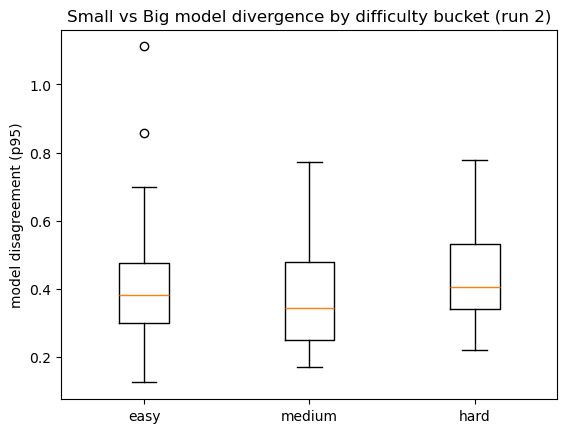

In [31]:
csv_path_2 = "/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen3-4B-Thinking-2507_vs_Qwen3-30B-A3B-Thinking-2507_1768516569.csv"
df2 = pd.read_csv(csv_path_2)

df2["ratio"] = df2["ratio_pA_over_pB"].clip(lower=1e-30)
df2["log10_ratio"] = np.log10(df2["ratio"])
df2["abs_log10_ratio"] = df2["log10_ratio"].abs()

per_problem_2 = df2.groupby(group_cols).agg(
    n_tokens=("token_idx", "count"),
    mean_abs_log10=("abs_log10_ratio", "mean"),
    p95_abs_log10=("abs_log10_ratio", lambda x: np.percentile(x, 95)),
    max_abs_log10=("abs_log10_ratio", "max"),
).reset_index()

data2 = [per_problem_2.loc[per_problem_2["bucket"]==b, "p95_abs_log10"].values for b in order]
plt.figure()
plt.boxplot(data2, labels=order)
plt.ylabel("model disagreement (p95)")
plt.title("Small vs Big model divergence by difficulty bucket (run 2)")
plt.show()



Ignoring the worst 5% of tokens, how large is the disagreement between the models on a problem ? 

Hypothesis: 

Observations: 




In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# df has ratio_pA_over_pB already
eps = 1e-30
df2 = df2.copy()
df2["ratio"] = df2["ratio_pA_over_pB"].clip(lower=eps)
df2["log_ratio"] = np.log(df2["ratio"])           # natural log
df2["abs_log_ratio"] = df2["log_ratio"].abs()

In [33]:
group_cols = ["seed", "example_id", "bucket", "level"]

per_problem = (
    df2.groupby(group_cols)
      .agg(
          n_tokens=("token_idx", "count"),
          p95_abs_log=("abs_log_ratio", lambda x: np.percentile(x, 95)),
          max_abs_log=("abs_log_ratio", "max"),
      )
      .reset_index()
)

# choose 1 example per bucket: "most divergent" by p95
rep = (
    per_problem.sort_values(["bucket", "p95_abs_log"], ascending=[True, False])
               .groupby("bucket", as_index=False)
               .head(1)
)
rep

,seed,example_id,bucket,level,n_tokens,p95_abs_log,max_abs_log
105,42,test_4332,easy,2,100,2.559570,6.765625
141,42,test_866,hard,5,100,1.790625,7.195312
31,42,test_1990,medium,3,100,1.779907,3.640625


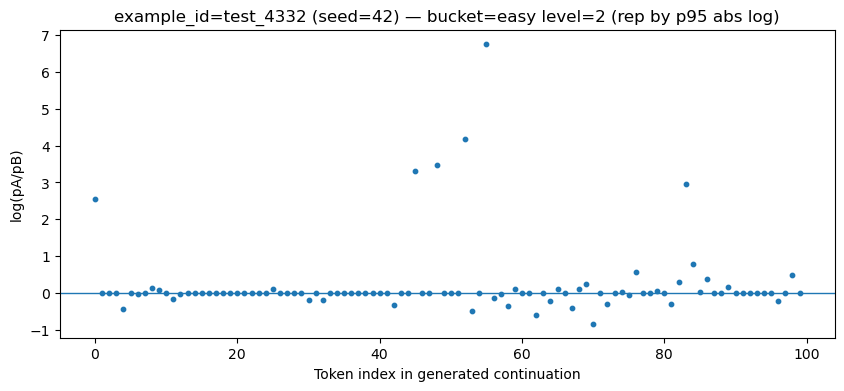

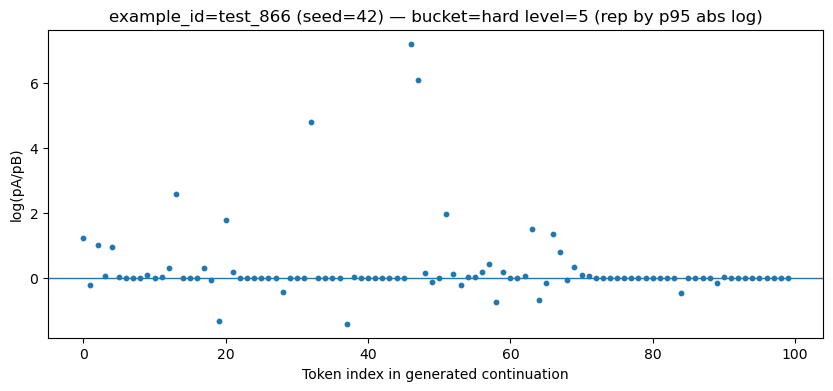

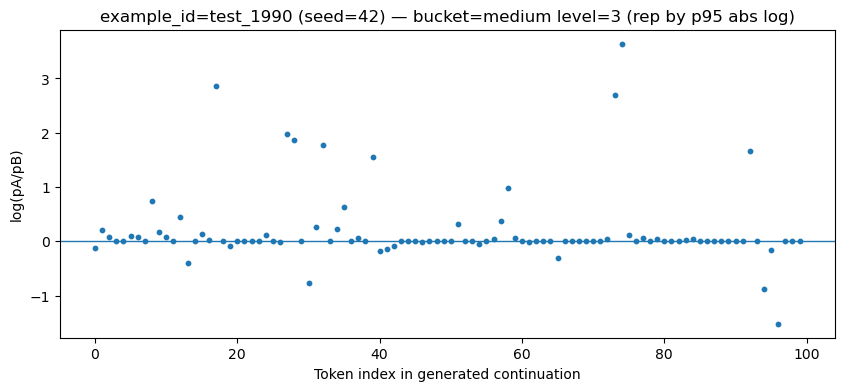

In [34]:
def plot_example_token_scatter(df, seed, example_id, title_suffix=""):
    g = df2[(df.seed == seed) & (df.example_id == example_id)].sort_values("token_idx")
    plt.figure(figsize=(10, 4))
    plt.scatter(g["token_idx"], g["log_ratio"], s=10)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Token index in generated continuation")
    plt.ylabel("log(pA/pB)")
    plt.title(f"example_id={example_id} (seed={seed}) {title_suffix}")
    plt.show()

for _, row in rep.iterrows():
    plot_example_token_scatter(
        df2,
        seed=row["seed"],
        example_id=row["example_id"],
        title_suffix=f"— bucket={row['bucket']} level={row['level']} (rep by p95 abs log)"
    )


In [35]:
"""
for bucket in ["easy","medium","hard"]:
    g = df2[df2.bucket == bucket]["log_ratio"]
    plt.figure(figsize=(5,3))
    plt.hist(g, bins=100, range=(-0.5,0.5), density=True)
    plt.title(f"{bucket}: density near zero")
    plt.xlabel("log(pA/pB)")
    plt.ylabel("density")
    plt.show()
    """


'\nfor bucket in ["easy","medium","hard"]:\n    g = df2[df2.bucket == bucket]["log_ratio"]\n    plt.figure(figsize=(5,3))\n    plt.hist(g, bins=100, range=(-0.5,0.5), density=True)\n    plt.title(f"{bucket}: density near zero")\n    plt.xlabel("log(pA/pB)")\n    plt.ylabel("density")\n    plt.show()\n    '

In [36]:
import numpy as np

df2 = df2.copy()

# spike definition
SPIKE_THR = 2.0  # log-scale, took 2 because of previous discussions
df2["is_spike"] = df2["abs_log_ratio"] >= SPIKE_THR
# normalize token position per (seed, example)
df2["max_token"] = df2.groupby(["seed","example_id"])["token_idx"].transform("max")
df2["rel_pos"] = df2["token_idx"] / df2["max_token"]

In [37]:
"""import matplotlib.pyplot as plt

for bucket in ["easy","medium","hard"]:
    g = df2[(df2.bucket == bucket) & (df2.is_spike)]
    plt.figure(figsize=(6,4))
    plt.hist(g["rel_pos"], bins=20, density=True)
    plt.xlabel("Relative token position")
    plt.ylabel("Density")
    plt.title(f"Spike position distribution — {bucket}")
    plt.show()
"""


'import matplotlib.pyplot as plt\n\nfor bucket in ["easy","medium","hard"]:\n    g = df2[(df2.bucket == bucket) & (df2.is_spike)]\n    plt.figure(figsize=(6,4))\n    plt.hist(g["rel_pos"], bins=20, density=True)\n    plt.xlabel("Relative token position")\n    plt.ylabel("Density")\n    plt.title(f"Spike position distribution — {bucket}")\n    plt.show()\n'

In [38]:
(df2[df2.is_spike]
 .groupby("bucket")["rel_pos"]
 .agg(["median","mean","count"]))


,median,mean,count
bucket,,,
easy,0.525253,0.490014,88
hard,0.373737,0.430748,59
medium,0.393939,0.441616,75


#### Interpretation: 
Medians: 
- Easy (0.52) : spikes later in generation
- Hard (0.37): earlier/mid reasoning
- Medium (0.4): in between

Hard problems cause early divergence in reasoning trajectories ? 

Let's see what tokens cause spikes

In [21]:
import re

def token_type(tok):
    if re.fullmatch(r"\d+", tok):
        return "number"
    if tok in {"+","-","*","/","=","^"}:
        return "operator"
    if tok.isalpha():
        return "word"
    return "other"




In [22]:
df2["tok_type"] = df2["token_str"].astype(str).map(token_type)

(df2.groupby(["bucket","tok_type"])
   .agg(
       spike_rate=("is_spike","mean"),
       n_tokens=("is_spike","size")
   )
   .sort_values(["bucket","spike_rate"], ascending=[True,False]))


NameError: name 'df2' is not defined

## 100 Q / bucket
/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen3-4B-Thinking-2507_vs_Qwen3-30B-A3B-Thinking-2507_1768559217.csv

/tmp/ipykernel_3510600/3789237098.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data3, labels=order)


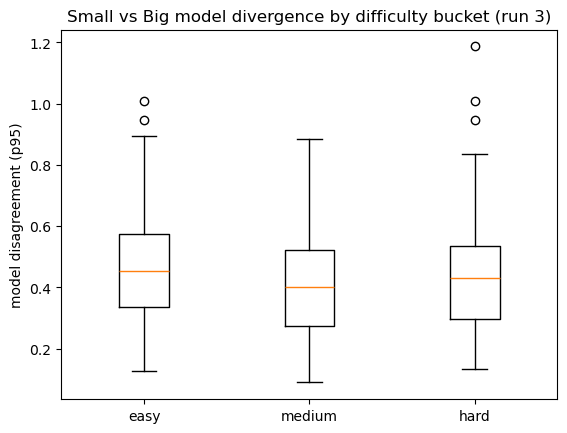

In [14]:
csv_path_3 = "/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen3-4B-Thinking-2507_vs_Qwen3-30B-A3B-Thinking-2507_1768559217.csv"
df3 = pd.read_csv(csv_path_3)

df3["ratio"] = df3["ratio_pA_over_pB"].clip(lower=1e-30)
df3["log10_ratio"] = np.log10(df3["ratio"])
df3["abs_log10_ratio"] = df3["log10_ratio"].abs()



per_problem_3 = df3.groupby(group_cols).agg(
    n_tokens=("token_idx", "count"),
    mean_abs_log10=("abs_log10_ratio", "mean"),
    p95_abs_log10=("abs_log10_ratio", lambda x: np.percentile(x, 95)),
    max_abs_log10=("abs_log10_ratio", "max"),
).reset_index()

data3 = [per_problem_3.loc[per_problem_3["bucket"]==b, "p95_abs_log10"].values for b in order]
plt.figure()
plt.boxplot(data3, labels=order)
plt.ylabel("model disagreement (p95)")
plt.title("Small vs Big model divergence by difficulty bucket (run 3)")
plt.show()

In [15]:
summary = (
    per_problem_3
    .groupby("bucket")["p95_abs_log10"]
    .agg(
        median="median",
        mean="mean",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count="count",
    )
    .reset_index()
)

summary


,bucket,median,mean,q25,q75,count
0,easy,0.454525,0.468827,0.336154,0.575313,100
1,hard,0.429544,0.441911,0.298100,0.534513,100
2,medium,0.400254,0.400013,0.272708,0.523698,100


## 200 Q / bucket

/tmp/ipykernel_3510600/3343225830.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data4, labels=order)


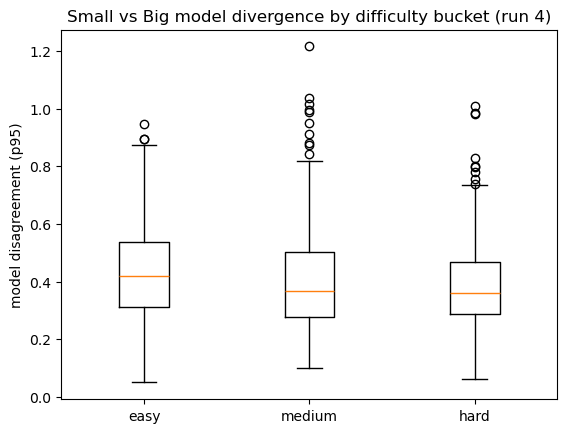

In [16]:
csv_path_4 = "/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen3-4B-Thinking-2507_vs_Qwen3-30B-A3B-Thinking-2507_1768569842.csv"
df4 = pd.read_csv(csv_path_4)

df4["ratio"] = df4["ratio_pA_over_pB"].clip(lower=1e-30)
df4["log10_ratio"] = np.log10(df4["ratio"])
df4["abs_log10_ratio"] = df4["log10_ratio"].abs()


per_problem_4 = df4.groupby(group_cols).agg(
    n_tokens=("token_idx", "count"),
    mean_abs_log10=("abs_log10_ratio", "mean"),
    p95_abs_log10=("abs_log10_ratio", lambda x: np.percentile(x, 95)),
    max_abs_log10=("abs_log10_ratio", "max"),
).reset_index()

data4 = [per_problem_4.loc[per_problem_4["bucket"]==b, "p95_abs_log10"].values for b in order]
plt.figure()
plt.boxplot(data4, labels=order)
plt.ylabel("model disagreement (p95)")
plt.title("Small vs Big model divergence by difficulty bucket (run 4)")
plt.show()

In [17]:
summary = (
    per_problem_4
    .groupby("bucket")["p95_abs_log10"]
    .agg(
        median="median",
        mean="mean",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count="count",
    )
    .reset_index()
)

summary


,bucket,median,mean,q25,q75,count
0,easy,0.419281,0.436922,0.311142,0.537121,200
1,hard,0.359769,0.394642,0.288647,0.468566,200
2,medium,0.368307,0.408151,0.276730,0.502673,200


/tmp/ipykernel_3598082/1344529733.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data5, labels=order)


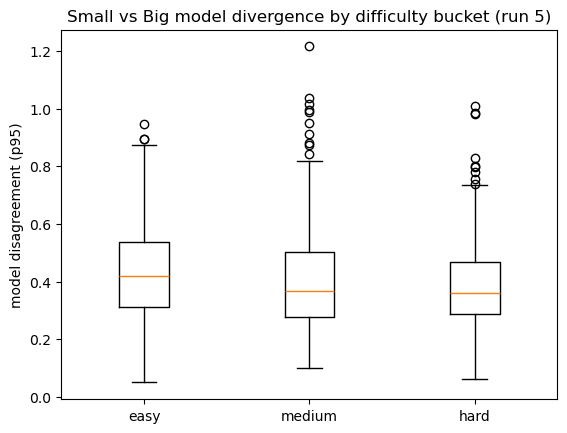

In [3]:
## trying to debug why the plots are different -- tried code 
csv_path_5 = "/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen3-4B-Thinking-2507_vs_Qwen3-30B-A3B-Thinking-2507_1768652019.csv"
df5 = pd.read_csv(csv_path_5)

df5["ratio"] = df5["ratio_pA_over_pB"].clip(lower=1e-30)
df5["log10_ratio"] = np.log10(df5["ratio"])
df5["abs_log10_ratio"] = df5["log10_ratio"].abs()   

per_problem_5 = df5.groupby(group_cols).agg(
    n_tokens=("token_idx", "count"),
    mean_abs_log10=("abs_log10_ratio", "mean"),
    p95_abs_log10=("abs_log10_ratio", lambda x: np.percentile(x, 95)),
    max_abs_log10=("abs_log10_ratio", "max"),
).reset_index()

data5 = [per_problem_5.loc[per_problem_5["bucket"]==b, "p95_abs_log10"].values for b in order]
plt.figure()
plt.boxplot(data5, labels=order)
plt.ylabel("model disagreement (p95)")
plt.title("Small vs Big model divergence by difficulty bucket (run 5)")
plt.show()

In [4]:
summary = (
    per_problem_5
    .groupby("bucket")["p95_abs_log10"]
    .agg(
        median="median",
        mean="mean",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count="count",
    )
    .reset_index()
)

summary

,bucket,median,mean,q25,q75,count
0,easy,0.419281,0.436922,0.311142,0.537121,200
1,hard,0.359769,0.394642,0.288647,0.468566,200
2,medium,0.368307,0.408151,0.276730,0.502673,200


In [5]:
df5.columns

Index(['seed', 'example_id', 'bucket', 'level', 'prompt', 'continuation_text',
       'token_idx', 'token_id', 'token_str', 'p_a', 'p_b', 'ratio_pA_over_pB',
       'ratio', 'log10_ratio', 'abs_log10_ratio'],
      dtype='object')

In [7]:
def get_generation(df, seed, example_id):
    g = (
        df5[(df5.seed == seed) & (df5.example_id == example_id)]
        .sort_values("token_idx")
    )
    return "".join(g["token_str"].tolist())

text = get_generation(df5, seed=42, example_id="test_1828")
print(text)

We know that in a right triangle, the sine of an angle is equal to the ratio of the length of the opposite side to the hypotenuse. For $30^\circ$, we can consider a special right triangle where one angle is $30^\circ$, another is $60^\circ$, and the third is $90^\circ$. In such a triangle, if the hypotenuse has length $2$, then the side opposite the $30^\circ$ angle has length $1$, and the side opposite the $60^\circ$ angle has length $\sqrt{3}$. Therefore, $\sin 30^\arg = \frac{\text{opposite}}{\text{hypotenuse}} = \frac{1}{2}$.

Wait, there's a typo in the solution. The angle should be written as $30^\circ$, not $30^\arg$. Let me correct it.

So, $\sin 30^\circ = \frac{1}{2}$.

Final answer: $\boxed{\dfrac{1}{2}}$
The problem asks for $\sin 30^\circ$. I remember from trigonometry that this is a standard angle with a known value. Let me think about how to verify it without relying on memorization.

I recall that in a unit circle, the sine of an angle corresponds to the y-coordinate of

Easy problems (unique example_id): 200
Easy rows (tokens): 59999
Easy spike tokens: 1127

Easy: spikes per problem (includes zeros)


,n_tokens,n_spikes,spike_rate,max_abs_log,p95_abs_log
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,299.995000,5.635000,0.018784,5.098661,1.006049
std,0.070711,3.724397,0.012418,3.188471,0.404618
min,299.000000,0.000000,0.000000,1.076172,0.114697
25%,300.000000,3.000000,0.010000,3.304688,0.716431
50%,300.000000,5.000000,0.016667,4.439453,0.965430
75%,300.000000,8.000000,0.026667,6.123047,1.236768
max,300.000000,19.000000,0.063333,34.046875,2.182031



Top 10 easy problems by spike count / max magnitude:


,seed,example_id,n_tokens,n_spikes,spike_rate,max_abs_log,p95_abs_log
95,42,test_3634,300,19,0.063333,5.611328,2.182031
36,42,test_1817,299,18,0.060201,5.500000,2.060937
158,42,test_4676,300,16,0.053333,5.269531,2.016406
167,42,test_4807,300,16,0.053333,4.921875,2.062305
194,42,test_966,300,15,0.050000,8.031250,1.971875
123,42,test_4122,300,15,0.050000,7.015625,1.838477
33,42,test_1782,300,15,0.050000,4.343750,1.844141
103,42,test_3790,300,14,0.046667,6.468750,1.892578
35,42,test_1812,300,14,0.046667,5.632812,1.969531
7,42,test_1187,300,14,0.046667,3.775391,1.678125


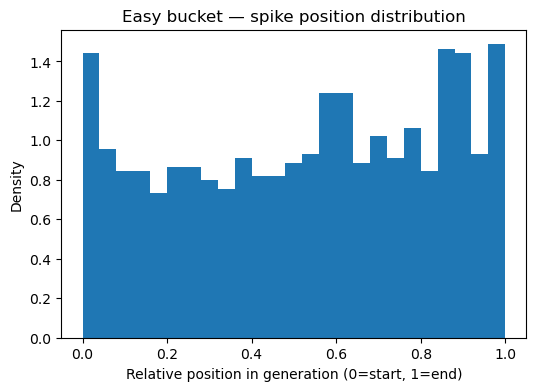


Easy spike position summary:


count    1127.000000
mean        0.528600
std         0.302521
min         0.000000
25%         0.265886
50%         0.561873
75%         0.795987
max         1.000000
Name: rel_pos, dtype: float64


Easy — spike rates by token type:


,n_tokens,spike_rate,n_spikes,mean_abs_log,max_abs_log
tok_type,,,,,
word,6167,0.034377,212,0.264315,34.046875
other,40912,0.021363,874,0.222813,14.378906
operator,2587,0.004252,11,0.068921,7.582031
number,10333,0.002903,30,0.026087,9.906250



Top 30 spike tokens in EASY by magnitude:


...

,token_idx,token_str,log_ratio,abs_log_ratio,mark
52388,189,\,1.192093e-07,1.192093e-07,
52389,190,)),-5.531311e-05,5.531311e-05,
52390,191,:\n\n,2.503395e-06,2.503395e-06,
52391,192,\,1.490116e-05,1.490116e-05,
52392,193,[\n,1.788139e-06,1.788139e-06,
52393,194,\,0.000000e+00,0.000000e+00,
52394,195,text,0.000000e+00,0.000000e+00,
52395,196,{,0.000000e+00,0.000000e+00,
52396,197,Interior,-1.633167e-05,1.633167e-05,
52397,198,Angle,1.192093e-07,1.192093e-07,



seed=42, example_id=test_1876, token_idx=150, token=' four', abs_log=14.379


,token_idx,token_str,log_ratio,abs_log_ratio,mark
25037,138,has,4.560547e+00,4.560547e+00,
25038,139,one,-1.316406e+00,1.316406e+00,
25039,140,tick,6.469727e-03,6.469727e-03,
25040,141,mark,9.218750e-01,9.218750e-01,
25041,142,\n,7.031250e-01,7.031250e-01,
25042,143,-,7.271767e-06,7.271767e-06,
25043,144,$,9.059906e-06,9.059906e-06,
25044,145,q,3.576279e-06,3.576279e-06,
25045,146,--,7.152557e-07,7.152557e-07,
25046,147,r,1.668930e-06,1.668930e-06,



seed=42, example_id=test_2568, token_idx=220, token='Finish', abs_log=10.656


,token_idx,token_str,log_ratio,abs_log_ratio,mark
9808,208,x,0.000140,0.000140,
9809,209,=,-0.000045,0.000045,
9810,210,,-0.000092,0.000092,
9811,211,4,-0.000003,0.000003,
9812,212,$,0.011749,0.011749,
9813,213,.\n\n,0.131104,0.131104,
9814,214,Final,0.316406,0.316406,
9815,215,answer,0.000309,0.000309,
9816,216,:,-0.000309,0.000309,
9817,217,,-0.021606,0.021606,


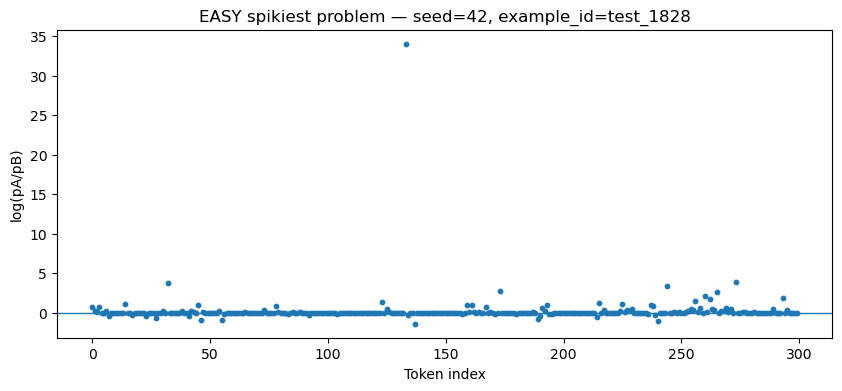


Spikiest easy problem summary:


seed                  42
example_id     test_1828
n_tokens             300
n_spikes               7
spike_rate      0.023333
max_abs_log    34.046875
p95_abs_log     1.098242
Name: 37, dtype: object

In [42]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

# ====== CONFIG ======
THR = 2.0                 # spike threshold on |log(pA/pB)|
WINDOW = 12               # context window in tokens
USE_LOG10 = False         # set True if you prefer log10; otherwise natural log

# ====== PREP ======
df = df4.copy()  # change to df3/df2/etc if needed

eps = 1e-30
df["ratio"] = df["ratio_pA_over_pB"].clip(lower=eps)

if USE_LOG10:
    df["log_ratio"] = np.log10(df["ratio"])
else:
    df["log_ratio"] = np.log(df["ratio"])

df["abs_log_ratio"] = df["log_ratio"].abs()
df["is_spike"] = df["abs_log_ratio"] >= THR

# Normalize position within each (seed, example_id)
df["max_token_idx"] = df.groupby(["seed","example_id"])["token_idx"].transform("max")
df["rel_pos"] = df["token_idx"] / df["max_token_idx"].replace(0, np.nan)

# Focus on easy bucket
easy = df[df["bucket"] == "easy"].copy()

print("Easy problems (unique example_id):", easy["example_id"].nunique())
print("Easy rows (tokens):", len(easy))
print("Easy spike tokens:", easy["is_spike"].sum())

# ====== 1) How many spikes per problem? (including zeros) ======
spikes_per_pb_easy = (
    easy.groupby(["seed","example_id"])
        .agg(
            n_tokens=("token_idx","count"),
            n_spikes=("is_spike","sum"),
            spike_rate=("is_spike","mean"),
            max_abs_log=("abs_log_ratio","max"),
            p95_abs_log=("abs_log_ratio", lambda x: np.percentile(x, 95)),
        )
        .reset_index()
)

print("\nEasy: spikes per problem (includes zeros)")
display(spikes_per_pb_easy[["n_tokens","n_spikes","spike_rate","max_abs_log","p95_abs_log"]].describe())

# Top spikiest problems
top_easy = spikes_per_pb_easy.sort_values(["n_spikes","max_abs_log"], ascending=[False, False]).head(10)
print("\nTop 10 easy problems by spike count / max magnitude:")
display(top_easy)

# ====== 2) Where do spikes happen within generation? ======
spike_positions_easy = easy[easy["is_spike"]]["rel_pos"].dropna()

plt.figure(figsize=(6,4))
plt.hist(spike_positions_easy, bins=25, density=True)
plt.xlabel("Relative position in generation (0=start, 1=end)")
plt.ylabel("Density")
plt.title("Easy bucket — spike position distribution")
plt.show()

print("\nEasy spike position summary:")
display(spike_positions_easy.describe())

# ====== 3) What token types spike? ======
def token_type(tok: str) -> str:
    tok = str(tok)
    if re.fullmatch(r"\d+", tok):
        return "number"
    if tok in {"+","-","*","/","=","^","(",")","[","]","{","}"}:
        return "operator"
    if tok.isalpha():
        return "word"
    return "other"

easy["tok_type"] = easy["token_str"].map(token_type)

tok_stats = (
    easy.groupby("tok_type")
        .agg(
            n_tokens=("tok_type","size"),
            spike_rate=("is_spike","mean"),
            n_spikes=("is_spike","sum"),
            mean_abs_log=("abs_log_ratio","mean"),
            max_abs_log=("abs_log_ratio","max"),
        )
        .sort_values("spike_rate", ascending=False)
)

print("\nEasy — spike rates by token type:")
display(tok_stats)

# ====== 4) Look at the actual tokens causing the biggest spikes ======
top_spike_tokens_easy = (
    easy[easy["is_spike"]]
        .sort_values("abs_log_ratio", ascending=False)
        .head(30)[["seed","example_id","token_idx","token_str","log_ratio","abs_log_ratio","rel_pos"]]
)

print("\nTop 30 spike tokens in EASY by magnitude:")
display(top_spike_tokens_easy)

# ====== 5) Context printing around spikes (so you can interpret them) ======
def show_spike_context(df_tokens: pd.DataFrame, seed: int, example_id: str, token_idx: int, window: int = 12):
    g = df_tokens[(df_tokens.seed==seed) & (df_tokens.example_id==example_id)].sort_values("token_idx")
    lo, hi = token_idx - window, token_idx + window
    ctx = g[(g.token_idx >= lo) & (g.token_idx <= hi)].copy()
    ctx["mark"] = np.where(ctx.token_idx==token_idx, "<<<SPIKE<<<", "")
    return ctx[["token_idx","token_str","log_ratio","abs_log_ratio","mark"]]

# Print contexts for the top 5 spikes (by magnitude) in EASY
print("\nContexts for top-5 spike tokens in EASY:")
for _, r in top_spike_tokens_easy.head(5).iterrows():
    print(f"\nseed={r.seed}, example_id={r.example_id}, token_idx={r.token_idx}, token='{r.token_str}', abs_log={r.abs_log_ratio:.3f}")
    display(show_spike_context(easy, r.seed, r.example_id, int(r.token_idx), window=WINDOW))

# ====== 6) Optional: plot token-level scatter for the single spikiest easy problem ======
spikiest_pb = spikes_per_pb_easy.sort_values(["max_abs_log","n_spikes"], ascending=False).head(1).iloc[0]
seed0, ex0 = int(spikiest_pb.seed), spikiest_pb.example_id

g = easy[(easy.seed==seed0) & (easy.example_id==ex0)].sort_values("token_idx")
plt.figure(figsize=(10,4))
plt.scatter(g["token_idx"], g["log_ratio"], s=10)
plt.axhline(0.0, linewidth=1)
plt.xlabel("Token index")
plt.ylabel("log(pA/pB)")
plt.title(f"EASY spikiest problem — seed={seed0}, example_id={ex0}")
plt.show()

print("\nSpikiest easy problem summary:")
display(spikiest_pb)
